# EDA Homework: Titanic Dataset

**dataset:** https://www.kaggle.com/competitions/titanic/data

пассажиры титаника: выжил/не выжил. 891 строка, 12 колонок.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)

## A) быстрый обзор данных

In [38]:
df = pd.read_csv('train.csv')
print('shape:', df.shape)

shape: (891, 12)


In [39]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [8]:
# проверка качества
print('пропуски:\n', df.isnull().sum())
print('\nдубликаты:', df.duplicated().sum())

пропуски:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

дубликаты: 0


## B) пропуски и очистка

In [9]:
# age: пропуски 177, заполняем медианой 
print('медиана age:', df['Age'].median())

медиана age: 28.0


In [10]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [11]:
# embarked: пропуски 2, заполняем модой (самый частый порт)
print('мода embarked:', df['Embarked'].mode()[0])
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

мода embarked: S


In [12]:
# cabin: много пропусков (687), удаляем колонку
df = df.drop('Cabin', axis=1)

In [13]:
# финальная проверка
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## C) расширенная статистика

In [14]:
# базовая статистика для числовых колонок
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']

for col in num_cols:
    print(f'\n{col}:')
    print(f'  min: {df[col].min():.2f}')
    print(f'  max: {df[col].max():.2f}')
    print(f'  mean: {df[col].mean():.2f}')
    print(f'  median: {df[col].median():.2f}')
    print(f'  mode: {df[col].mode().values[0]:.2f}')


Age:
  min: 0.42
  max: 80.00
  mean: 29.36
  median: 28.00
  mode: 28.00

Fare:
  min: 0.00
  max: 512.33
  mean: 32.20
  median: 14.45
  mode: 8.05

SibSp:
  min: 0.00
  max: 8.00
  mean: 0.52
  median: 0.00
  mode: 0.00

Parch:
  min: 0.00
  max: 6.00
  mean: 0.38
  median: 0.00
  mode: 0.00


In [15]:
# перцентили
for col in num_cols:
    print(f'\n{col}:')
    percentiles = np.percentile(df[col], [5, 25, 50, 75, 95])
    print(f'  5%: {percentiles[0]:.2f}')
    print(f'  25%: {percentiles[1]:.2f}')
    print(f'  50%: {percentiles[2]:.2f}')
    print(f'  75%: {percentiles[3]:.2f}')
    print(f'  95%: {percentiles[4]:.2f}')


Age:
  5%: 6.00
  25%: 22.00
  50%: 28.00
  75%: 35.00
  95%: 54.00

Fare:
  5%: 7.22
  25%: 7.91
  50%: 14.45
  75%: 31.00
  95%: 112.08

SibSp:
  5%: 0.00
  25%: 0.00
  50%: 0.00
  75%: 1.00
  95%: 3.00

Parch:
  5%: 0.00
  25%: 0.00
  50%: 0.00
  75%: 0.00
  95%: 2.00


In [41]:
# дисперсия, асимметрия, эксцесс
for col in num_cols:
    print(f'\n{col}:')
    print(f'  дисперсия: {df[col].var():.2f}')
    print(f'  асимметрия: {df[col].skew():.2f}')
    print(f'  эксцесс: {df[col].kurtosis():.2f}')


Age:
  дисперсия: 211.02
  асимметрия: 0.39
  эксцесс: 0.18

Fare:
  дисперсия: 2469.44
  асимметрия: 4.79
  эксцесс: 33.40

SibSp:
  дисперсия: 1.22
  асимметрия: 3.70
  эксцесс: 17.88

Parch:
  дисперсия: 0.65
  асимметрия: 2.75
  эксцесс: 9.78


In [17]:
# интерпретация
print('интерпретация:')
print('- variance: разброс данных вокруг среднего')
print('- skewness > 0: правосторонняя асимметрия (хвост справа)')
print('- skewness < 0: левосторонняя асимметрия')
print('- kurtosis > 0: тяжёлые хвосты, больше выбросов')
print('- kurtosis < 0: лёгкие хвосты, меньше выбросов')
print('\nFare имеет сильную правостороннюю асимметрию и тяжёлые хвосты - много дорогих билетов')

интерпретация:
- variance: разброс данных вокруг среднего
- skewness > 0: правосторонняя асимметрия (хвост справа)
- skewness < 0: левосторонняя асимметрия
- kurtosis > 0: тяжёлые хвосты, больше выбросов
- kurtosis < 0: лёгкие хвосты, меньше выбросов

Fare имеет сильную правостороннюю асимметрию и тяжёлые хвосты - много дорогих билетов


## D) фичи: энкодинг и инжиниринг

In [18]:
df_enc = df.copy()
print('до энкодинга:', df_enc.shape)

до энкодинга: (891, 11)


In [42]:

cat_cols = ['Sex', 'Embarked']
df_onehot = pd.get_dummies(df_enc, columns=cat_cols, drop_first=True)
df_onehot.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True


In [20]:
# label encoding для Pclass (вручную через map)
pclass_map = {1: 0, 2: 1, 3: 2}
df_onehot['Pclass_encoded'] = df_onehot['Pclass'].map(pclass_map)

In [21]:
# feature hashing для Name (простая хеш-функция)
def simple_hash(text, n_features=5):
    return hash(text) % n_features

df_onehot['name_hash'] = df_onehot['Name'].apply(lambda x: simple_hash(x))
df_onehot[['Name', 'name_hash']].head()

,Name,name_hash
0,"Braund, Mr. Owen Harris",4
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",3
2,"Heikkinen, Miss. Laina",0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",3
4,"Allen, Mr. William Henry",4


In [22]:
# генерация новых фич
# 1. family size
df_onehot['FamilySize'] = df_onehot['SibSp'] + df_onehot['Parch'] + 1

# 2. is alone
df_onehot['IsAlone'] = (df_onehot['FamilySize'] == 1).astype(int)

# 3. age group
df_onehot['AgeGroup'] = pd.cut(df_onehot['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['child', 'teen', 'adult', 'middle', 'senior'])

# 4. fare per person
df_onehot['FarePerPerson'] = df_onehot['Fare'] / df_onehot['FamilySize']

df_onehot[['FamilySize', 'IsAlone', 'AgeGroup', 'FarePerPerson']].head()

,FamilySize,IsAlone,AgeGroup,FarePerPerson
0,2,0,adult,3.62500
1,2,0,middle,35.64165
2,1,1,adult,7.92500
3,2,0,adult,26.55000
4,1,1,adult,8.05000


In [23]:
# группировка редких категорий
df_onehot['SibSp_grouped'] = df_onehot['SibSp'].apply(lambda x: x if x < 3 else '3+')
df_onehot['Parch_grouped'] = df_onehot['Parch'].apply(lambda x: x if x < 3 else '3+')

## E) визуализация

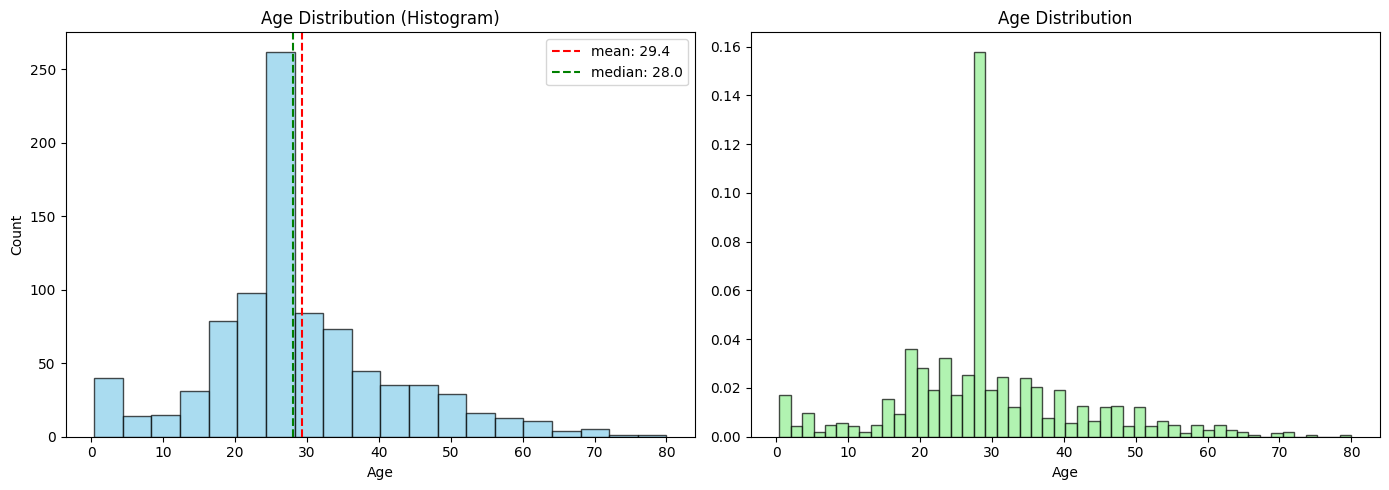

In [24]:
# 1. распределение Age (histogram)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(df['Age'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
ax[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'mean: {df["Age"].mean():.1f}')
ax[0].axvline(df['Age'].median(), color='green', linestyle='--', label=f'median: {df["Age"].median():.1f}')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Count')
ax[0].set_title('Age Distribution (Histogram)')
ax[0].legend()

# KDE вручную через гистограмму с большим числом бинов
ax[1].hist(df['Age'], bins=50, density=True, alpha=0.7, color='lightgreen', edgecolor='black')
ax[1].set_xlabel('Age')
ax[1].set_title('Age Distribution')

plt.tight_layout()
plt.show()

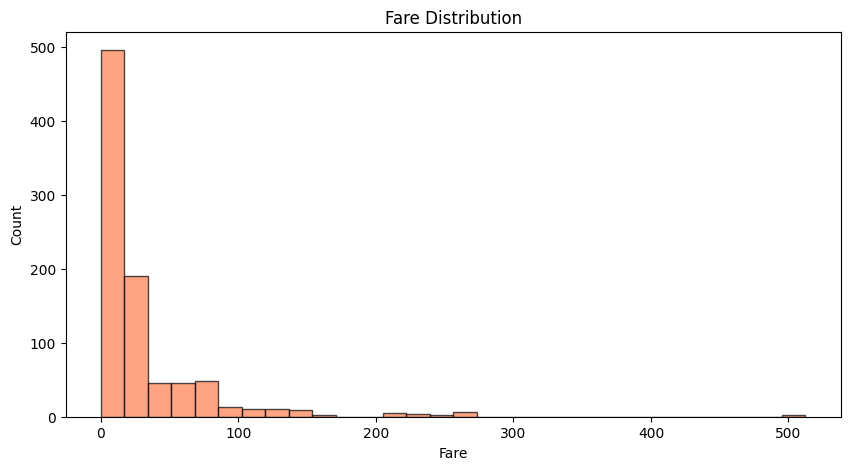

In [25]:
# 2. распределение Fare
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Fare'], bins=30, edgecolor='black', alpha=0.7, color='coral')
ax.set_xlabel('Fare')
ax.set_ylabel('Count')
ax.set_title('Fare Distribution')
plt.show()

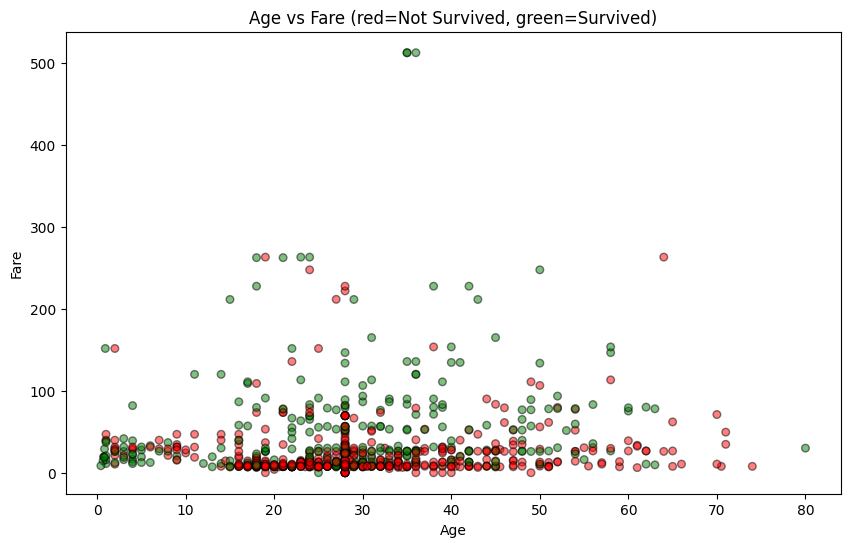

In [26]:
# 3. scatter plot: Age vs Fare
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if s == 0 else 'green' for s in df['Survived']]
ax.scatter(df['Age'], df['Fare'], c=colors, alpha=0.5, edgecolors='black', s=30)
ax.set_xlabel('Age')
ax.set_ylabel('Fare')
ax.set_title('Age vs Fare (red=Not Survived, green=Survived)')
plt.show()

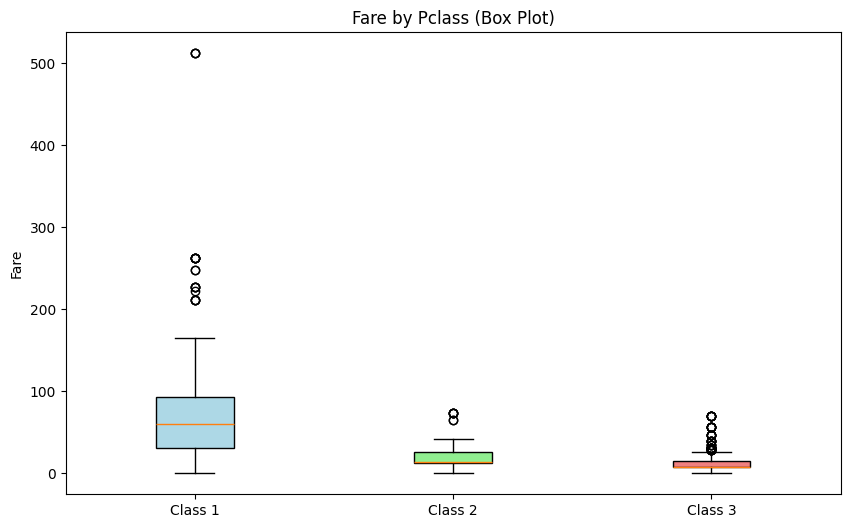

In [27]:
# 4. box plot вручную: Fare по классам
fig, ax = plt.subplots(figsize=(10, 6))

data = [df[df['Pclass'] == c]['Fare'].values for c in sorted(df['Pclass'].unique())]
labels = [f'Class {c}' for c in sorted(df['Pclass'].unique())]

bp = ax.boxplot(data, labels=labels, patch_artist=True)
colors_box = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)

ax.set_ylabel('Fare')
ax.set_title('Fare by Pclass (Box Plot)')
plt.show()

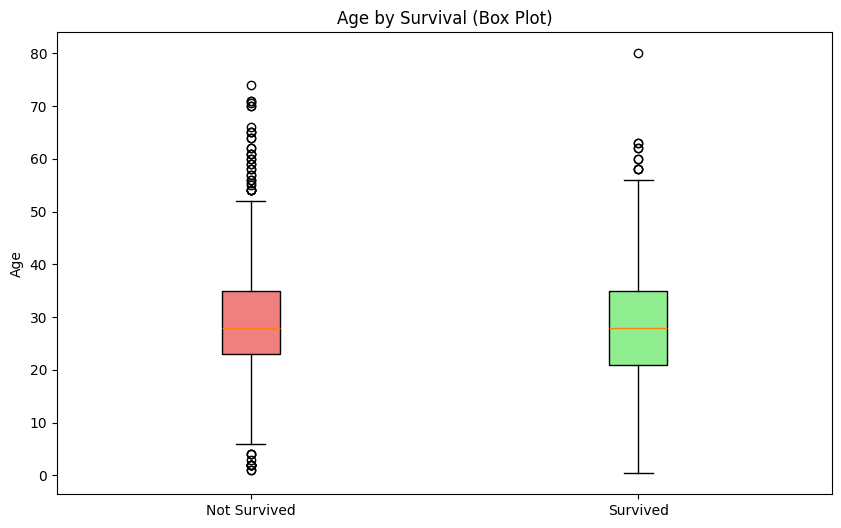

In [28]:
# 5. box plot: Age по выжившим
fig, ax = plt.subplots(figsize=(10, 6))

data = [df[df['Survived'] == s]['Age'].values for s in [0, 1]]
labels = ['Not Survived', 'Survived']

bp = ax.boxplot(data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightcoral', 'lightgreen']):
    patch.set_facecolor(color)

ax.set_ylabel('Age')
ax.set_title('Age by Survival (Box Plot)')
plt.show()

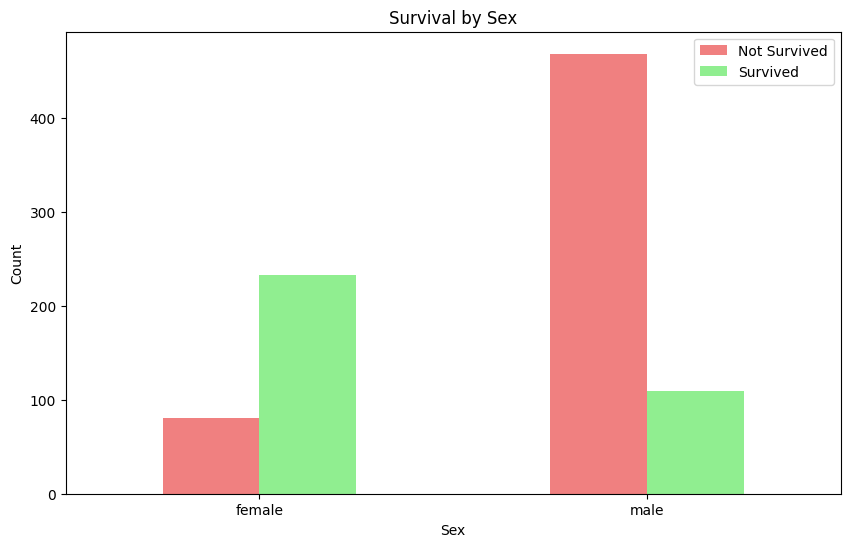

In [29]:
# 6. bar plot: выживание по полу
fig, ax = plt.subplots(figsize=(10, 6))

sex_survived = df.groupby(['Sex', 'Survived']).size().unstack(fill_value=0)
sex_survived.plot(kind='bar', ax=ax, color=['lightcoral', 'lightgreen'])
ax.set_xlabel('Sex')
ax.set_ylabel('Count')
ax.set_title('Survival by Sex')
ax.legend(['Not Survived', 'Survived'])
plt.xticks(rotation=0)
plt.show()

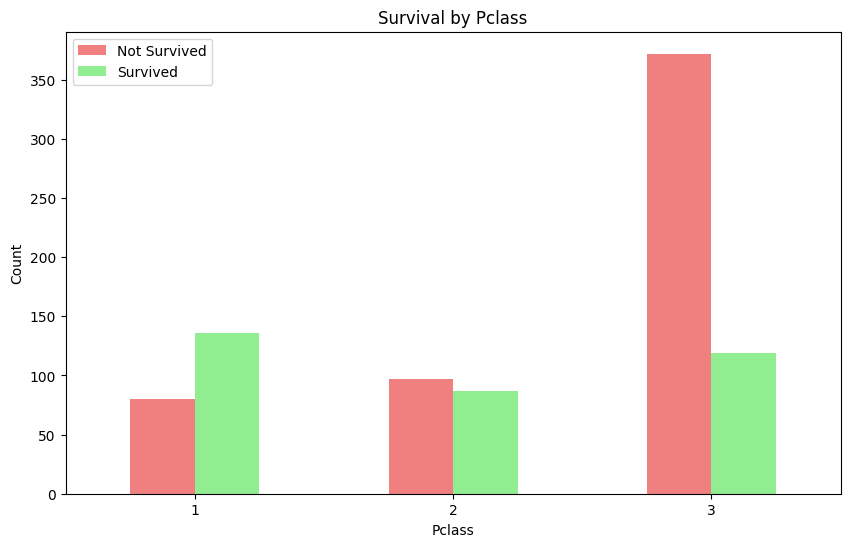

In [30]:
# 7. bar plot: выживание по классу
fig, ax = plt.subplots(figsize=(10, 6))

class_survived = df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
class_survived.plot(kind='bar', ax=ax, color=['lightcoral', 'lightgreen'])
ax.set_xlabel('Pclass')
ax.set_ylabel('Count')
ax.set_title('Survival by Pclass')
ax.legend(['Not Survived', 'Survived'])
plt.xticks(rotation=0)
plt.show()

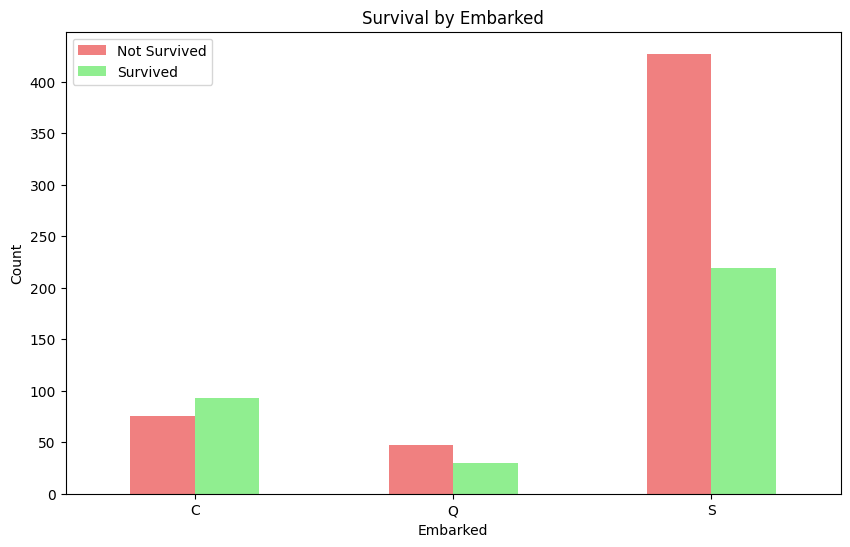

In [31]:
# 8. bar plot: выживание по Embarked
fig, ax = plt.subplots(figsize=(10, 6))

embarked_survived = df.groupby(['Embarked', 'Survived']).size().unstack(fill_value=0)
embarked_survived.plot(kind='bar', ax=ax, color=['lightcoral', 'lightgreen'])
ax.set_xlabel('Embarked')
ax.set_ylabel('Count')
ax.set_title('Survival by Embarked')
ax.legend(['Not Survived', 'Survived'])
plt.xticks(rotation=0)
plt.show()

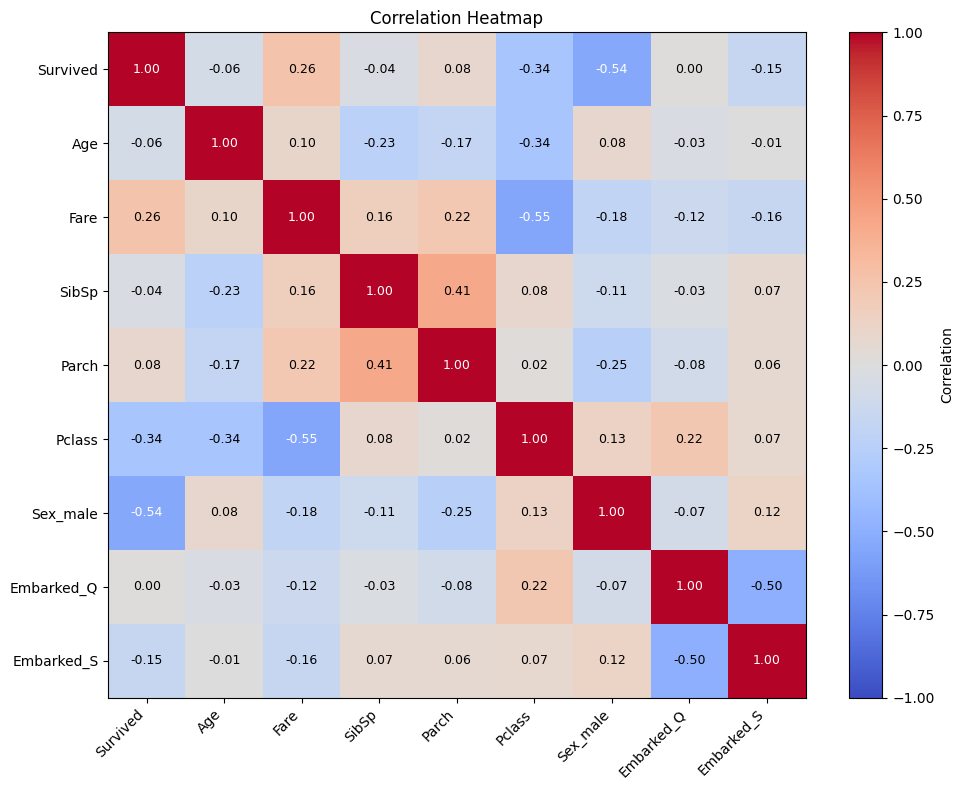

выводы по корреляциям:
- Sex_male: -0.54 с Survived (женщины выживали чаще)
- Pclass: -0.34 с Survived (1 класс выживал чаще)
- Fare: 0.26 с Survived (дорогие билеты = выше выживание)


In [32]:
# 9. heatmap корреляций (вручную через imshow)
corr_cols = ['Survived', 'Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Sex_male', 'Embarked_Q', 'Embarked_S']
corr_matrix = df_onehot[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)

# добавляем значения
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im, ax=ax, label='Correlation')
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print('выводы по корреляциям:')
print('- Sex_male: -0.54 с Survived (женщины выживали чаще)')
print('- Pclass: -0.34 с Survived (1 класс выживал чаще)')
print('- Fare: 0.26 с Survived (дорогие билеты = выше выживание)')

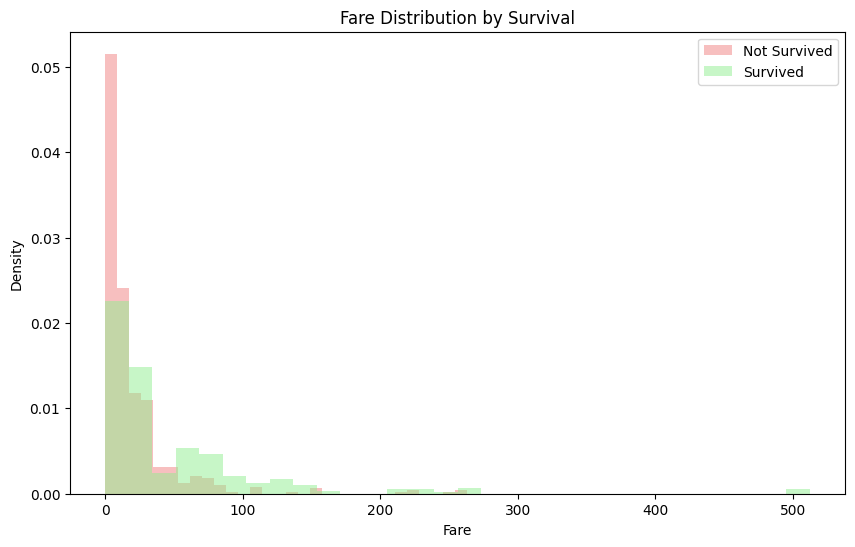

In [33]:
# 10. violin plot вручную через гистограммы
fig, ax = plt.subplots(figsize=(10, 6))

for s, label, color in [(0, 'Not Survived', 'lightcoral'), (1, 'Survived', 'lightgreen')]:
    data = df[df['Survived'] == s]['Fare']
    ax.hist(data, bins=30, density=True, alpha=0.5, color=color, label=label)

ax.set_xlabel('Fare')
ax.set_ylabel('Density')
ax.set_title('Fare Distribution by Survival')
ax.legend()
plt.show()

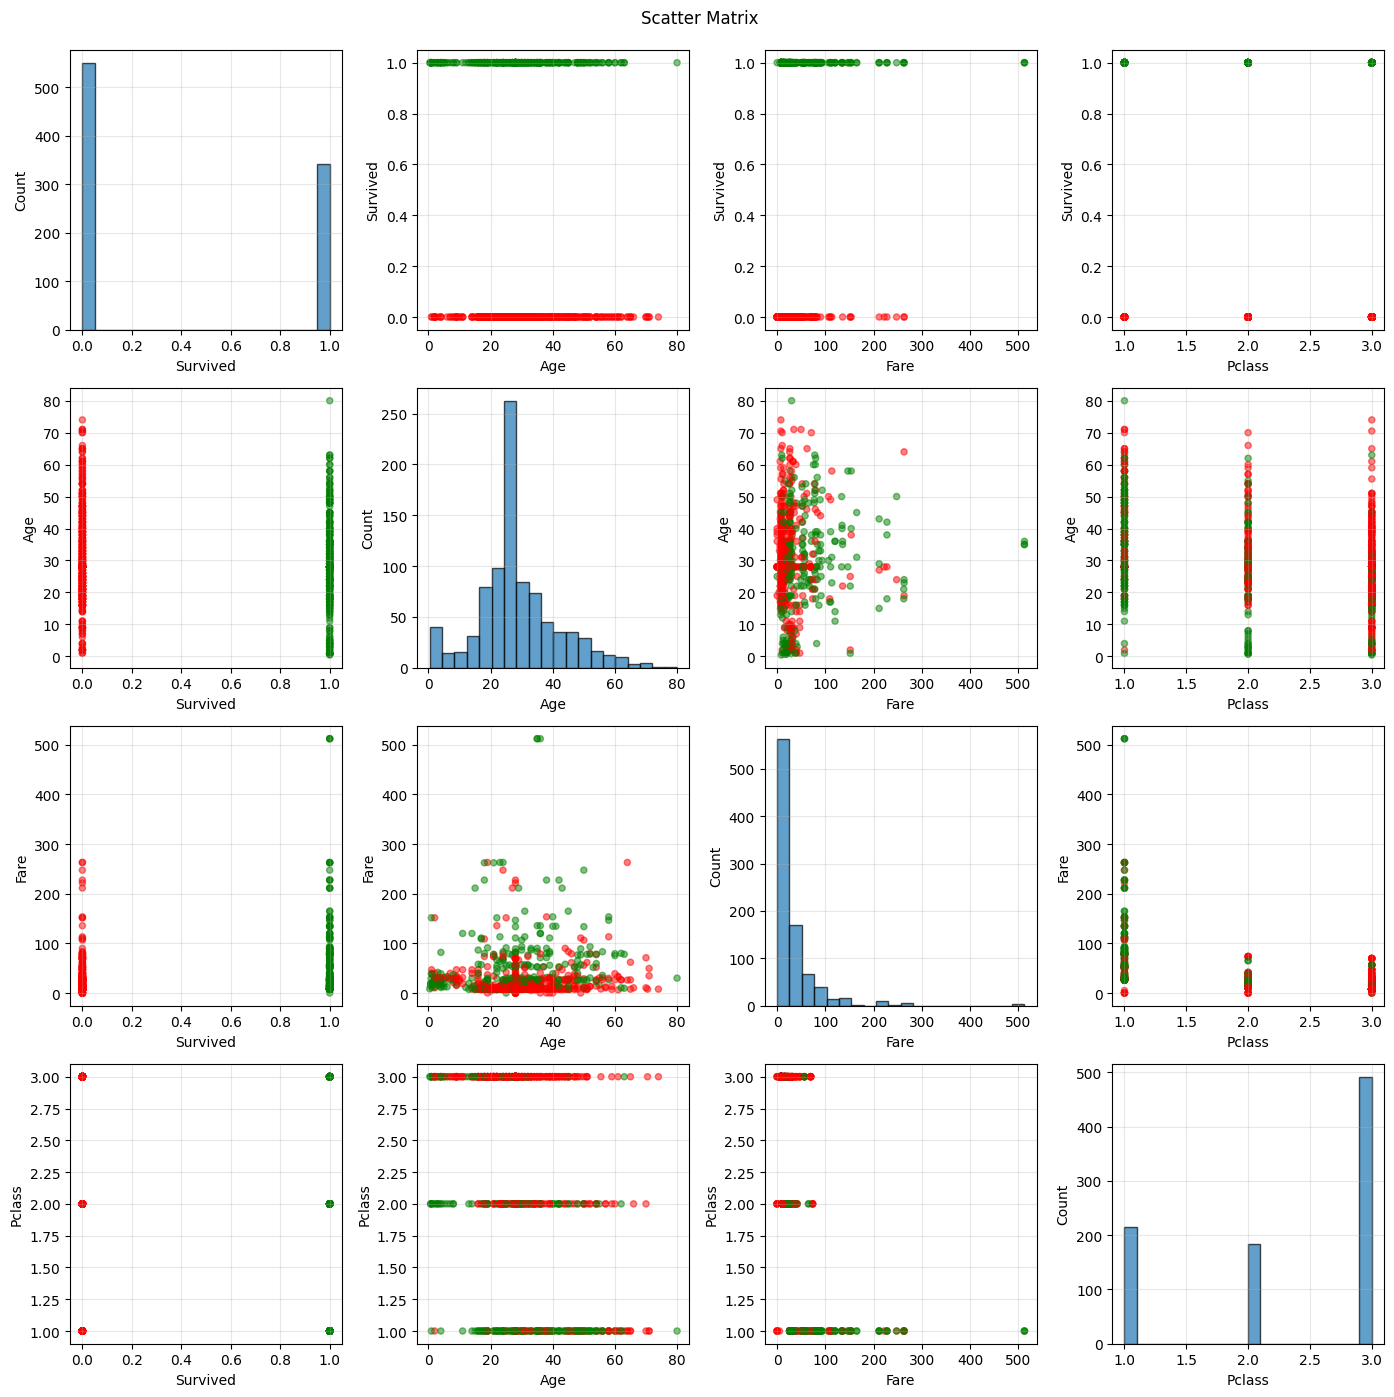

In [34]:
# 11. scatter matrix (pairplot вручную)
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
cols = ['Survived', 'Age', 'Fare', 'Pclass']

for i, col1 in enumerate(cols):
    for j, col2 in enumerate(cols):
        ax = axes[i, j]
        if i == j:
            ax.hist(df[col1], bins=20, edgecolor='black', alpha=0.7)
            ax.set_xlabel(col1)
            ax.set_ylabel('Count')
        else:
            colors = ['red' if s == 0 else 'green' for s in df['Survived']]
            ax.scatter(df[col2], df[col1], c=colors, alpha=0.5, s=20)
            ax.set_xlabel(col2)
            ax.set_ylabel(col1)
        ax.grid(True, alpha=0.3)

plt.suptitle('Scatter Matrix', y=0.995)
plt.tight_layout()
plt.show()

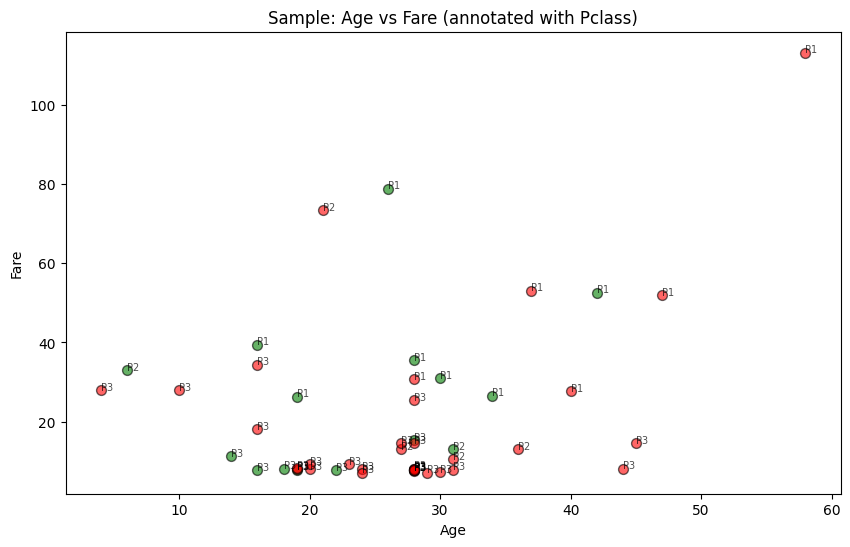

In [35]:
# 12. интерактивный plot через matplotlib widgets (опционально)
# для простоты - статичный график с подписями
fig, ax = plt.subplots(figsize=(10, 6))

for idx, row in df.sample(50, random_state=42).iterrows():
    color = 'green' if row['Survived'] == 1 else 'red'
    ax.scatter(row['Age'], row['Fare'], c=color, alpha=0.6, edgecolors='black', s=50)
    ax.annotate(f"P{row['Pclass']}", (row['Age'], row['Fare']), fontsize=7, alpha=0.7)

ax.set_xlabel('Age')
ax.set_ylabel('Fare')
ax.set_title('Sample: Age vs Fare (annotated with Pclass)')
plt.show()

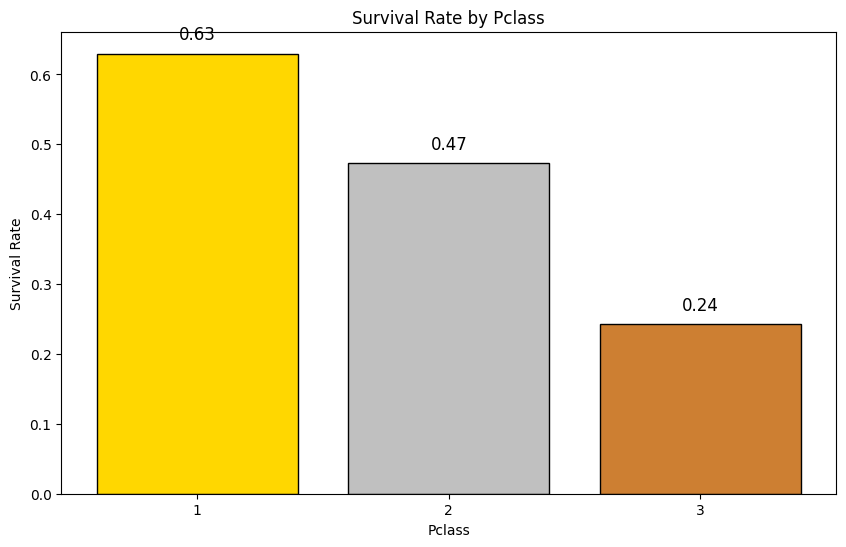

In [36]:
# 13. bar chart: survival rate by class
fig, ax = plt.subplots(figsize=(10, 6))

survival_rate = df.groupby('Pclass')['Survived'].mean()
ax.bar(survival_rate.index, survival_rate.values, color=['#FFD700', '#C0C0C0', '#CD7F32'], edgecolor='black')
ax.set_xlabel('Pclass')
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by Pclass')
ax.set_xticks([1, 2, 3])

# добавляем значения на столбцы
for i, v in enumerate(survival_rate.values):
    ax.text(i + 1, v + 0.02, f'{v:.2f}', ha='center', fontsize=12)

plt.show()

## F) итоговые выводы

### что я понял про датасет:

1. всего 891 пассажир, 38% выжили
2. женщин выжило значительно больше (~74%), мужчин ~19%
3. 1 класс имел наивысший шанс выживания (~63%), 3 класс ~24%
4. средний возраст ~30 лет, много детей и подростков
5. Fare сильно скошен вправо, есть дорогие выбросы (>500)
6. большинство ехало в 3 классе (55%)
7. большинство село в порту S (Southampton)
8. Cabin имеет 77% пропусков - колонка бесполезна
9. FamilySize варьируется от 1 до 11
10. IsAlone = 1 у 60% пассажиров
11. сильная корреляция: Pclass-Fare (-0.55), Sex_male-Survived (-0.54)
12. Age не имеет сильной корреляции с выживанием

### гипотезы и наблюдения:

1. женщины и дети приоритетно сажались в шлюпки (исторический факт "women and children first")
2. пассажиры 1 класса имели лучший доступ к шлюпкам (ближе к палубе)
3. большие семьи (FamilySize > 4) выживали реже - сложнее было держаться вместе
4. порт посадки S имел низкий процент выживания - там село много 3 класса
5. цена билеля (Fare) сильно коррелирует с классом и выживанием